# Optimizer

Basic optimizer

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from math import radians
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from environment import LauncherV1Orbital, Stage
from case_runner import CaseRunner
from plotting import Plotter

In [3]:
env = LauncherV1Orbital({
    "dt": 0.05,
    # "theta_e_random_window": radians(30),
    # "stages": (
    #     Stage( 
    #         dry_mass=1,
    #         propellant_mass=0.95,
    #         specific_impulse=400,
    #         thrust=4*1.7),
    # ),
    # "initial_theta_e": radians(15),
    # "autopilot_mode": AP_FLIGHT_PATH_CONTROL,
    # "initial_kepler": {
    #     "a": moon_radius + 100e3,
    #     "e": .0,
    #     "true_anomaly": 0.,
    # }
})
env

/home/adewindt/repos/thesis/code/trajectory_optimization_1/traj1/environments/launcher_v1/simulation.py:121: NumbaWarning: Cannot cache compiled function "new_simulation" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @nb.jit(nopython=True, cache=True)


In [4]:
def generate_result_path(results_path: Path, note: str):
    name = datetime.now().strftime(f'%Y_%m_%d_%H_%M_%S_%f__{note}')
    path = (results_path / name).resolve()
    path.mkdir()
    return path
    

results_path = Path('./results') / "manual"
results_path.mkdir(exist_ok=True)

In [5]:
case_runner = CaseRunner(
    env=env,
    max_time=1000,
    n_checkpoints=4,
    results_path=generate_result_path(results_path, "")
)

In [111]:
x = np.array([[
    200., 400., 645.,
    200., 400,
    radians(90.), radians(45.), radians(0.), radians(0.),
]])

# x = [
#     200., 400., 800.,
#     200., 400,
#     radians(90.), radians(60.), radians(10.), radians(0.),
# ]s

# x = np.array([[ 3.76823221e+02,  2.74796296e+02,  3.69703073e+02,  6.85730048e+02,
#          9.65621806e+02,  4.69189614e-01, -4.94731205e-02, -3.34992689e-01,
#         -1.44996166e-01]])

x = np.array([[ 3.44952528e+02,  4.86701113e+02,  5.41803430e+02,  4.05475863e+02,
         5.93935065e+02,  7.90831604e-01, -7.71211919e-02, -3.61320996e-01,
         1.03726819e-01]])

x = np.array([[ 3.82716991e+02,  8.53602651e+02,  4.50229082e+02,  7.41407714e+02,
         5.78484180e+02,  5.92867693e-01,  1.58647503e-01, -5.81787777e-01,
         8.00750425e-01 ]])

case_runner(x)

array([0.9699659])

In [112]:
plotter = Plotter(env, case_runner.last_result)

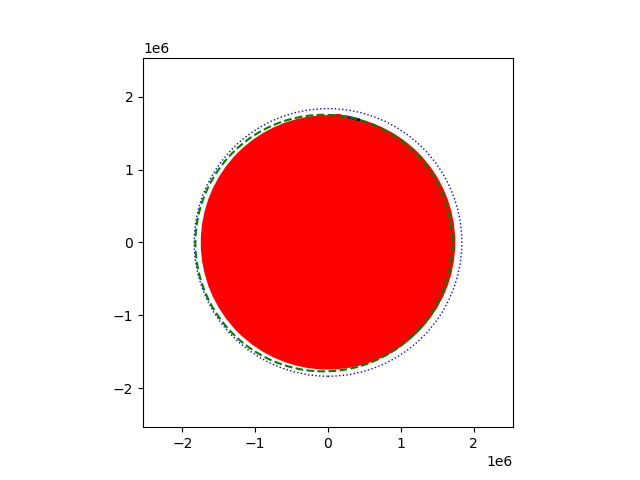

In [113]:
plotter.orbit_view();

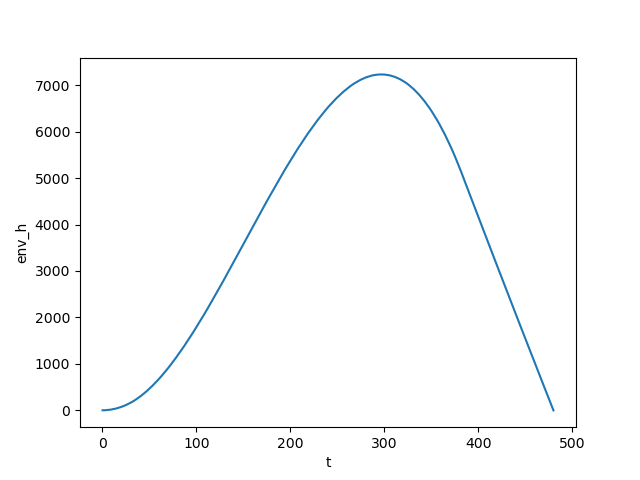

In [114]:
plotter.alt();

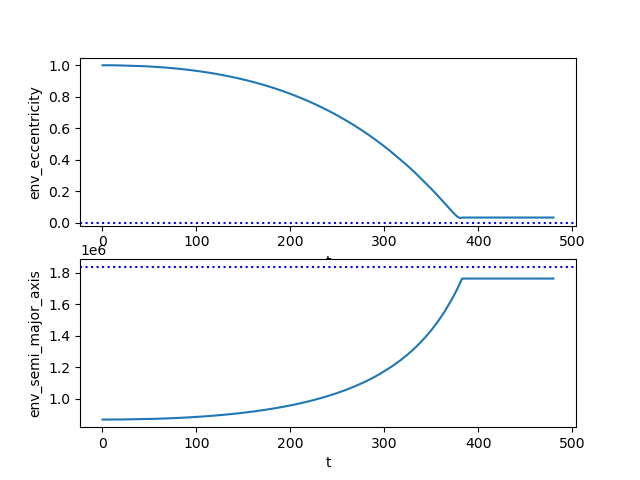

In [115]:
plotter.orbital_elements();

In [13]:
1 - (env.target_a - env.target_h) / env.target_a

0.05442473059758357

## Plot cost function

In [100]:
def sigmoid(x):
    return x / np.sqrt(1 + x * x)

def cost_function(target_a, a, e):
    a_error = abs(target_a - a) / target_a
    return (
        sigmoid(a_error*1000)**2
        + sigmoid(e * 50)**2
    )

In [101]:
eps = np.finfo(np.float32).eps

n = 1000
hs = np.linspace(env.target_a - env.target_h, env.target_a + 0.1 * env.target_h, n)
es = np.linspace(-.1, 1, n)

hv, ev = np.meshgrid(hs, es)

cost = cost_function(env.target_a, hv, ev)
plt.close('all')

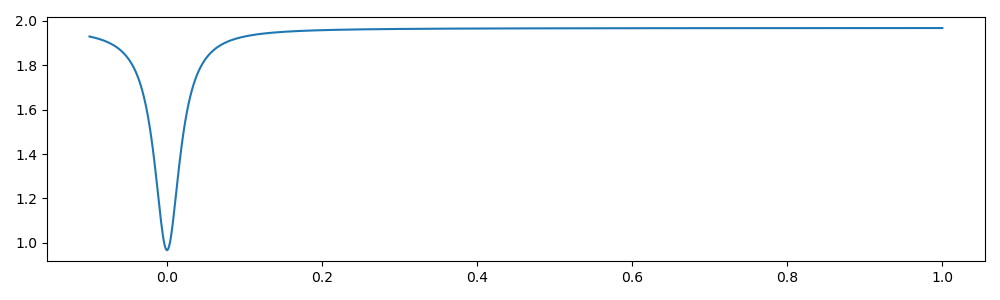

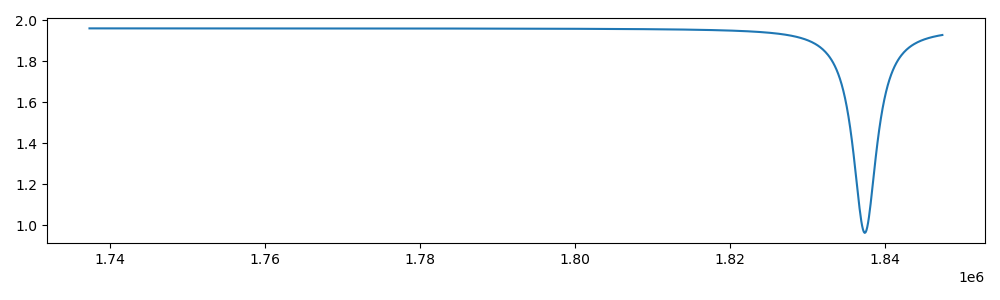

In [102]:
fig = plt.figure(figsize=(10, 3))
s = slice(None), n -1
plt.plot(ev[s].flatten(), cost[s].flatten());
plt.tight_layout()

fig = plt.figure(figsize=(10, 3))
s = 0, slice(None)
plt.plot(hv[s].flatten(), cost[s].flatten());
plt.tight_layout()

# x = np.linspace(-1, 1, 100)
# y = abs(sigmoid(x*2))
# plt.plot(x, y)
# plt.plot(x, x**2)

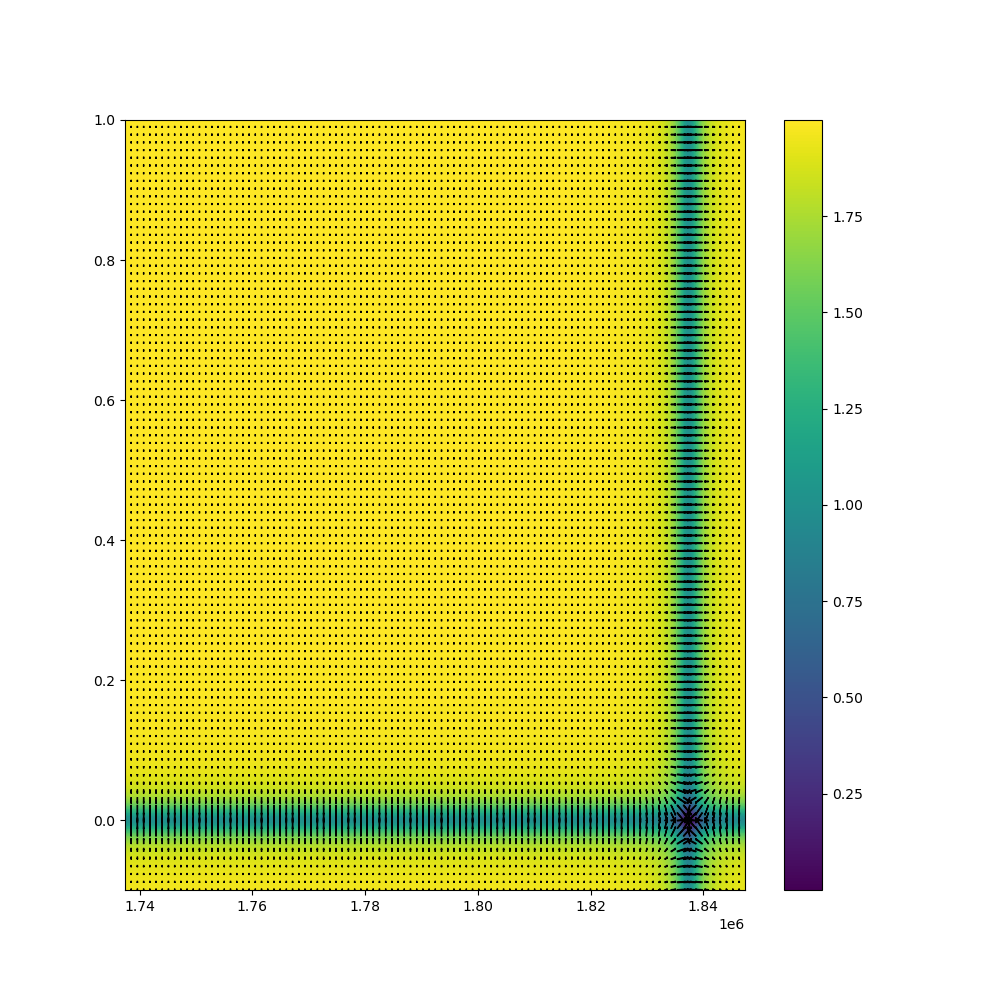

In [110]:
fig = plt.figure(figsize=(10, 10))

dsc = 10
yd, xd = np.gradient(-cost[::dsc, ::dsc])
aspect_ratio = (max(hs) - min(hs)) / (max(es) - min(es))

def func_to_vectorize(x, y, dx, dy, scaling=10):
    plt.arrow(x, y, dx*scaling*aspect_ratio, dy*scaling, fc="k", ec="k", 
              # head_width=0.01, head_length=1000
    )

vectorized_arrow_drawing = np.vectorize(func_to_vectorize)

c = plt.pcolormesh(hv, ev, cost)

vectorized_arrow_drawing(hv[::dsc, ::dsc], ev[::dsc, ::dsc], xd, yd, .05)

fig.colorbar(c);
plt.xlim([min(hs), max(hs)]);
plt.ylim([min(es), max(es)]);

## Optimize

In [76]:
x = [
    200., 400., 650.,
    0., 200., 400, 1500,
    radians(90.), radians(45.), radians(0.), radians(0.),
]

res = minimize(case_runner, x)
res


KeyboardInterrupt

